In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

In [2]:
df = pd.read_csv ("ml_features_and_labels.csv")
df.head ()

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e1b_ciphersuite_60,e2b_tls_version_SSL3.0,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,split,taxonomy,ID
0,8182,4.7889,5.8077,2.45,149.827957,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,train,eval_test_network,net_high_jitter_classic_run1
1,8126,5.0000,5.8367,2.44,231.020927,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,val,eval_test_network,net_high_jitter_classic_run10
2,8272,4.7889,5.9056,2.73,292.967796,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,train,eval_test_network,net_high_jitter_classic_run100
3,8272,4.8125,5.9056,2.31,156.050205,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,test,eval_test_network,net_high_jitter_classic_run101
4,8272,4.8125,5.8367,4.45,193.972111,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,test,eval_test_network,net_high_jitter_classic_run102


In [3]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       37500 non-null  float64
 3   e6_time_char                       39010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     39510 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               39010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  bool   
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  bool   
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  bool   
 11  e1_alg_suite_mlkem1024             40010 non-null  bool   
 12  e

In [4]:
df.describe ()

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,label
count,40010.000000,40010.000000,37500.000000,39010.000000,40010.000000,39510.000000,40010.000000,39010.000000,40010.000000
mean,12734.864859,4.880134,5.289081,1.882544,46.039189,863.392559,1100.269683,5510.472187,0.125219
std,6276.814331,0.112110,0.699216,1.624671,337.839188,650.984442,652.325633,1383.064765,0.330971
min,285.000000,0.000000,4.001800,0.070000,0.000000,32.000000,129.000000,2.000000,0.000000
25%,8206.000000,4.812500,4.436600,0.830000,4.619837,32.000000,285.000000,5324.000000,0.000000
50%,10412.000000,4.875000,5.778700,1.200000,5.376935,1184.000000,1429.000000,5330.000000,0.000000
75%,19207.000000,4.937500,5.876600,2.460000,6.694078,1568.000000,1813.000000,5333.000000,0.000000
max,22615.000000,5.000000,6.108500,94.150000,4522.223949,1568.000000,1813.000000,7502.000000,1.000000


In [5]:
df.groupby('label').mean(numeric_only=True).T

label,0,1
e2c_total_bytes,13565.918257,6929.102595
e4_entropy_h,4.881626,4.869714
e5_entropy_c,5.289167,5.287872
e6_time_char,1.983515,1.001247
e6b_flow_duration_ms,5.957071,326.053983
e2_client_size,838.400000,1057.348115
e2_client_record_len,1086.600000,1195.766467
e2_server_record_len,5761.400000,3320.329177
e3_cert_parsed,0.000000,0.099800
e1_alg_suite_Unknown(0x11eb),0.000000,0.001996


In [6]:
# clean data
X = df[['e6b_flow_duration_ms', 'e2c_total_bytes', 'e2_server_record_len']]
y = df['label']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

# model
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.147155
         Iterations 17
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                39010
Model:                          Logit   Df Residuals:                    39006
Method:                           MLE   Df Model:                            3
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.5557
Time:                        00:43:49   Log-Likelihood:                -5740.5
converged:                       True   LL-Null:                       -12919.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  554.6873     38.861     14.274      0.000     478.521     630.85

In [7]:
np.exp(model.params)

const                   7.899948e+240
e6b_flow_duration_ms     1.046210e+00
e2c_total_bytes          1.000148e+00
e2_server_record_len     9.002441e-01
dtype: float64

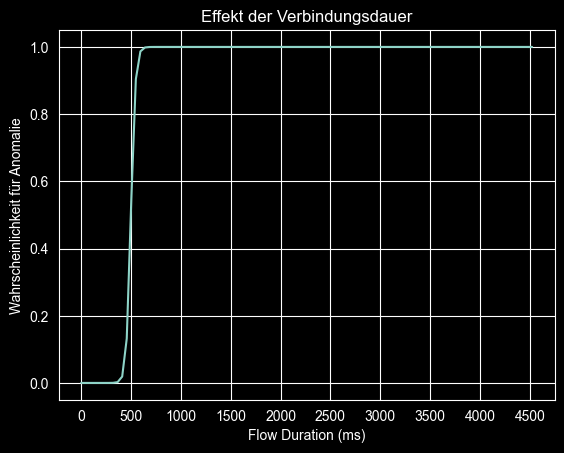

In [8]:
# Wertebereich
flow_range = np.linspace(df['e6b_flow_duration_ms'].min(),
                         df['e6b_flow_duration_ms'].max(), 100)

# Mittelwerte der anderen Variablen
bytes_mean = df['e2c_total_bytes'].mean()
server_mean = df['e2_server_record_len'].mean()

# Designmatrix
X_plot = pd.DataFrame({
    'const': 1,
    'e6b_flow_duration_ms': flow_range,
    'e2c_total_bytes': bytes_mean,
    'e2_server_record_len': server_mean
})

# Vorhersage
preds = model.predict(X_plot)

# Plot
plt.figure()
plt.plot(flow_range, preds)
plt.xlabel('Flow Duration (ms)')
plt.ylabel('Wahrscheinlichkeit für Anomalie')
plt.title('Effekt der Verbindungsdauer')
plt.xticks(np.arange(0, df['e6b_flow_duration_ms'].max(), 500))
#plt.axvline(x=500, linestyle='--')
plt.show()

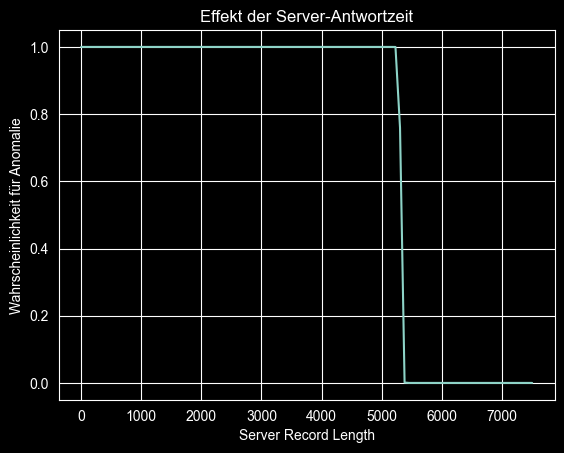

In [9]:
# Wertebereich
server_range = np.linspace(df['e2_server_record_len'].min(),
                           df['e2_server_record_len'].max(), 100)

# Mittelwerte der anderen Variablen
flow_mean = df['e6b_flow_duration_ms'].mean()
bytes_mean = df['e2c_total_bytes'].mean()

# Designmatrix
X_plot = pd.DataFrame({
    'const': 1,
    'e6b_flow_duration_ms': flow_mean,
    'e2c_total_bytes': bytes_mean,
    'e2_server_record_len': server_range
})

# Vorhersage
preds = model.predict(X_plot)

# Plot
plt.figure()
plt.plot(server_range, preds)
plt.xlabel('Server Record Length')
plt.ylabel('Wahrscheinlichkeit für Anomalie')
plt.title('Effekt der Server-Antwortzeit')
plt.xticks(np.arange(0, df['e2_server_record_len'].max(), 1000))

plt.show()

In [15]:
prior = df['label'].mean()
print("Prior P(Anomalie):", prior)

Prior P(Anomalie): 0.12521869532616844


In [28]:
for x in [300, 400, 500, 600, 700]:
    X = pd.DataFrame({
        'const': [1],
        'e6b_flow_duration_ms': [x],
        'e2c_total_bytes': [df['e2c_total_bytes'].mean()],
        'e2_server_record_len': [df['e2_server_record_len'].mean()]
    })
    print(x, model.predict(X)[0])

300 0.0001275595125077641
400 0.01155108347884071
500 0.517014558763837
600 0.9899045807093843
700 0.9998886776315129


In [29]:
for x in [4800, 5000, 5200, 5400, 5600]:
    X = pd.DataFrame({
        'const': [1],
        'e6b_flow_duration_ms': [df['e6b_flow_duration_ms'].mean()],
        'e2c_total_bytes': [df['e2c_total_bytes'].mean()],
        'e2_server_record_len': [x]
    })
    print(x, model.predict(X)[0])

4800 1.0
5000 0.9999999999999962
5200 0.9999949088285198
5400 0.00014627453424252584
5600 1.089643533365973e-13


In [31]:
X_normal = pd.DataFrame({
    'const': [1],
    'e6b_flow_duration_ms': [300],
    'e2c_total_bytes': [df['e2c_total_bytes'].mean()],
    'e2_server_record_len': [5600]
})

posterior_normal = model.predict(X_normal)[0]
print("Posterior P(Anomalie bei unauffälligen Werten):", posterior_normal)

Posterior P(Anomalie bei unauffälligen Werten): 1.0465071701090541e-08


In [30]:
X_anomaly = pd.DataFrame({
    'const': [1],
    'e6b_flow_duration_ms': [600],
    'e2c_total_bytes': [df['e2c_total_bytes'].mean()],
    'e2_server_record_len': [5100]
})

posterior_anomaly = model.predict(X_anomaly)[0]
print("Posterior P(Anomalie bei auffälligen Werten):", posterior_anomaly)

Posterior P(Anomalie bei auffälligen Werten): 1.0


In [10]:
plot_df = pd.DataFrame({
    'server_record_len': server_range,
    'predicted_prob': preds
})

plot_df.to_csv('server_plot.csv', index=False)

In [11]:
plot_df2 = pd.DataFrame({
    'flow_duration': flow_range,
    'predicted_prob': preds
})

plot_df2.to_csv('flow_plot.csv', index=False)